In [ ]:
!uv pip install "napari[all]>0.5.6"

  × Failed to read `numpy==2.2.4`
  ├─▶ Failed to read metadata from installed package `numpy==2.2.4`
  ╰─▶ failed to open file
      `D:\zeiss\Documents\GitHub\napari-demo\.venv\Lib\site-packages\numpy-2.2.4.dist-info\METADATA`:
      The system cannot find the file specified. (os error 2)
  help: `numpy` (v2.2.4) was included because `napari` (v0.6.0a1) depends
        on `numpy>=1.24.2`


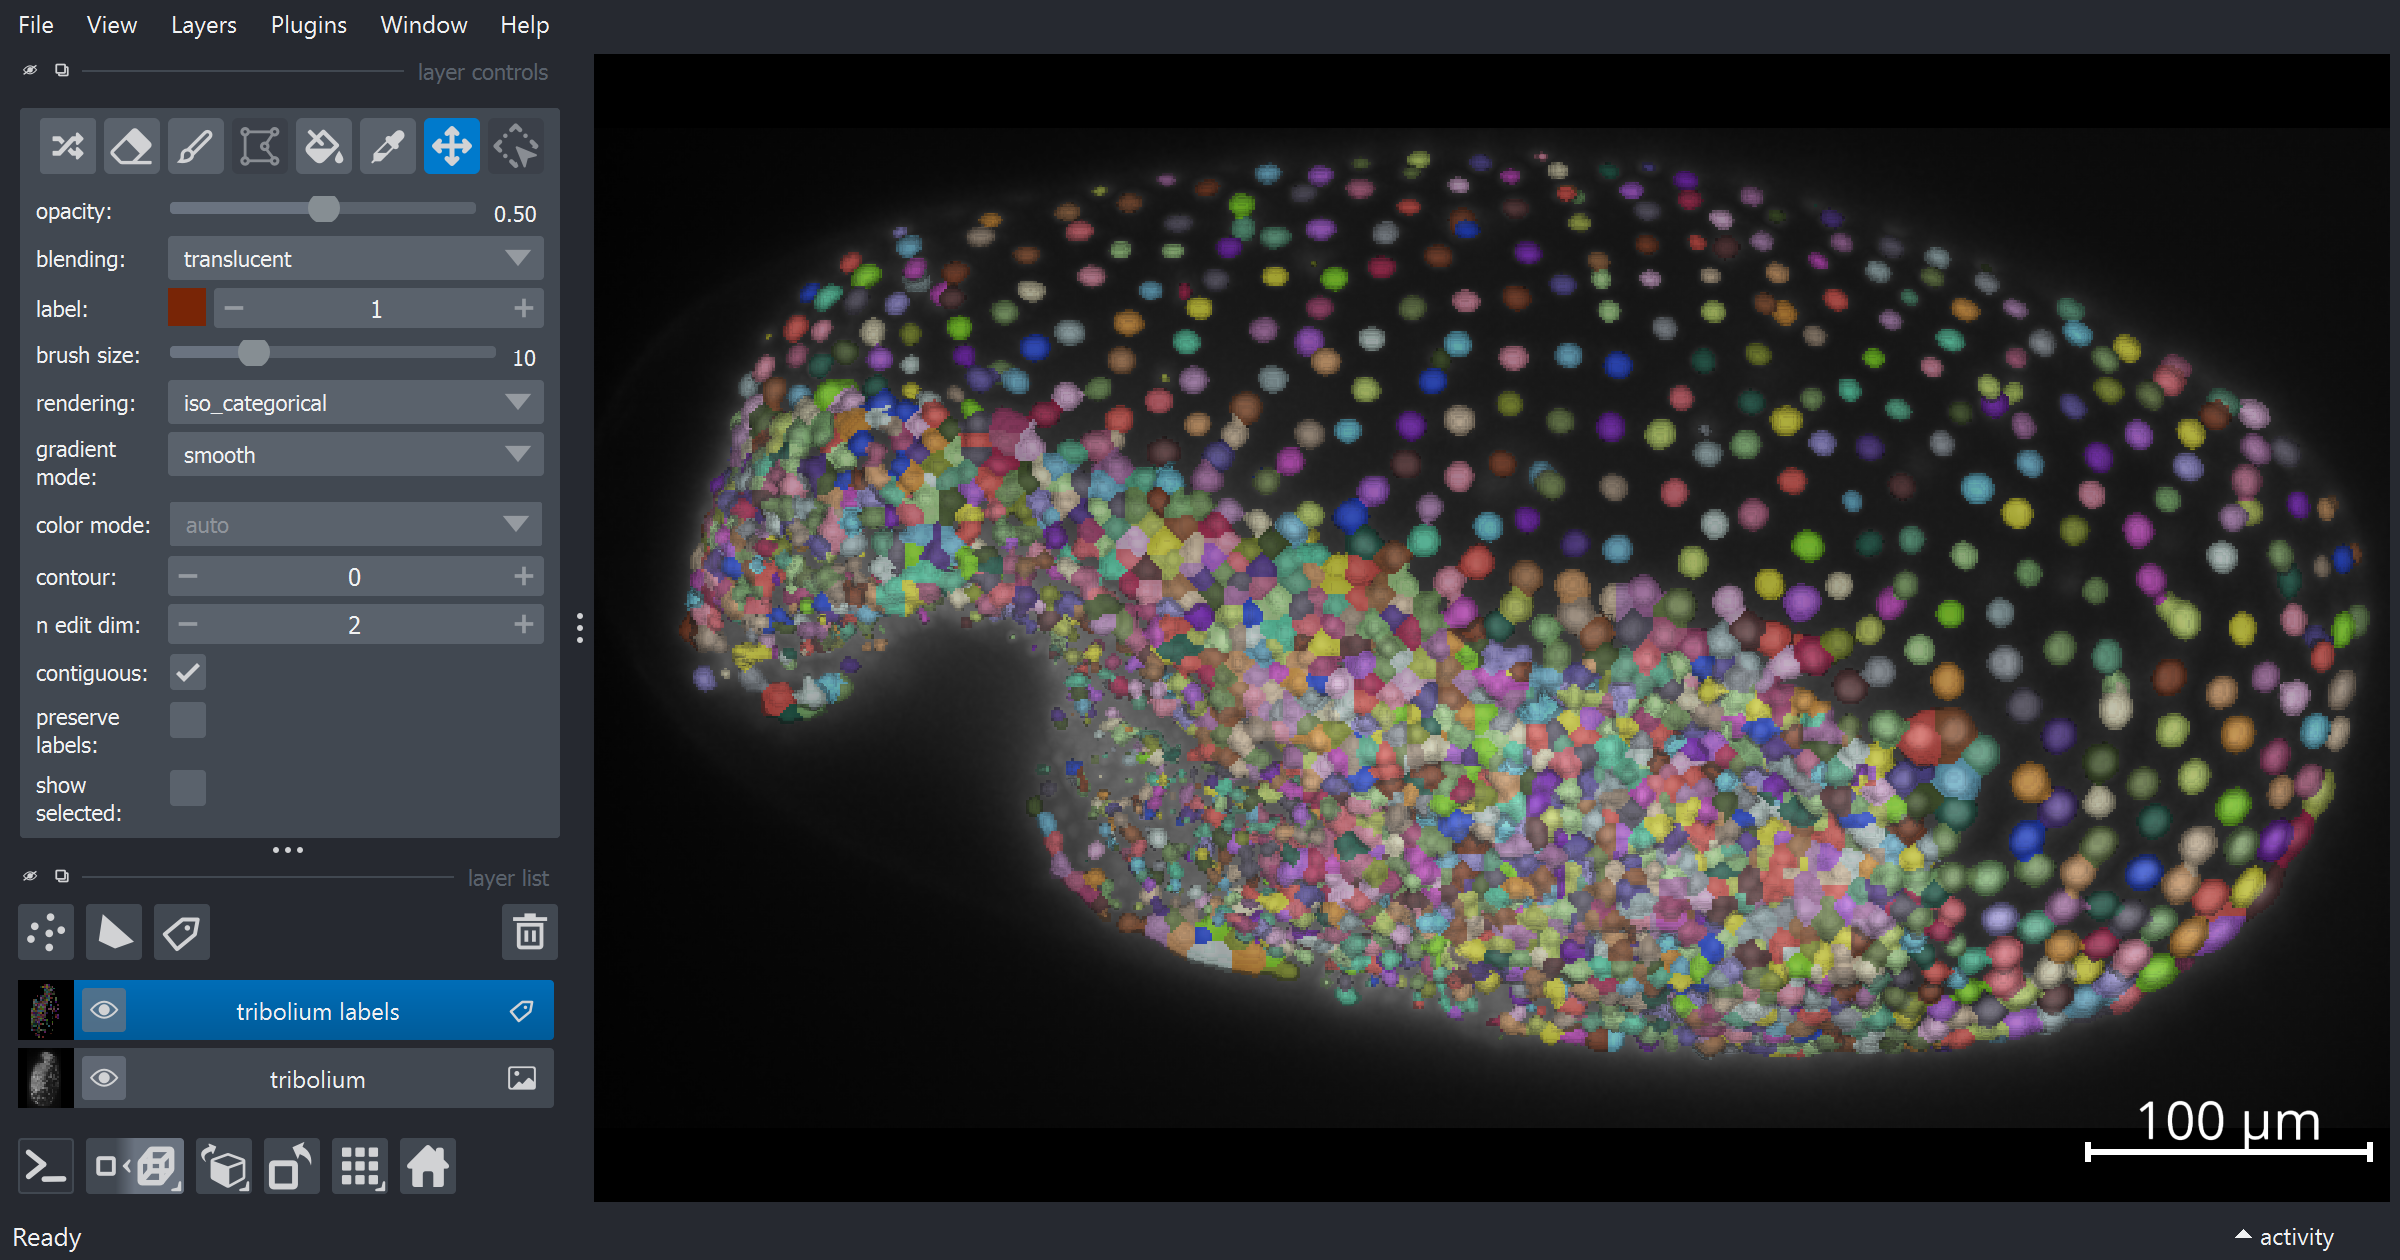

In [1]:
import scipy.ndimage as ndimage
from skimage import filters, measure, morphology, segmentation
from skimage.io import imread

import napari
from napari.utils import nbscreenshot

# TZYX tribolium image
raw_image = imread(r'https://github.com/clEsperanto/clesperanto_example_data/raw/main/Lund-100MB.tif')

# keep only the first timepoint of this image
img = raw_image[1, :, :, :]

# use a tophat filter to remove the background
img_bs = ndimage.white_tophat(img, size = 15)

# blur the image to smooth out noise from the background subtraction
img_blur = filters.gaussian(img_bs, 1)

# detect maxima in the blurred image for watershed seeds
img_spot_maxima = morphology.local_maxima(img_blur)

# create a threshold mask
img_otsu = img_blur > filters.threshold_otsu(img_blur)

# keep only maxima spots that are inside a thresholded area
img_threshold_spots = img_spot_maxima * img_otsu

# create a connected components labeling of the thresholded image
# using the local maxima as markers, as a seed for a voronoi diagram
img_labeled_spots = measure.label(img_threshold_spots)
img_labels = segmentation.watershed(
    img_otsu,
    markers=img_labeled_spots,
    mask=img_otsu
)

viewer = napari.Viewer()

image = viewer.add_image(img, name='tribolium')
labels = viewer.add_labels(
    img_labels,
    name='tribolium labels',
    opacity=0.5,
    iso_gradient_mode = 'smooth'
)

viewer.dims.ndisplay = 3
viewer.camera.angles = (90, 0, 90)
viewer.window.resize(1200, 630)
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'μm'
viewer.scale_bar.font_size = 20
viewer.fit_to_view(margin=0)

screenshot = viewer.screenshot(path='tribolium_viewer.png', canvas_only=False)

nbscreenshot(viewer)